In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn wordcloud nltk textblob -q

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  
Missing values:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64
R2 Score: 0.9673373873539192
MAE: 0.5907950819672131
RMSE: 0.8674113062799534


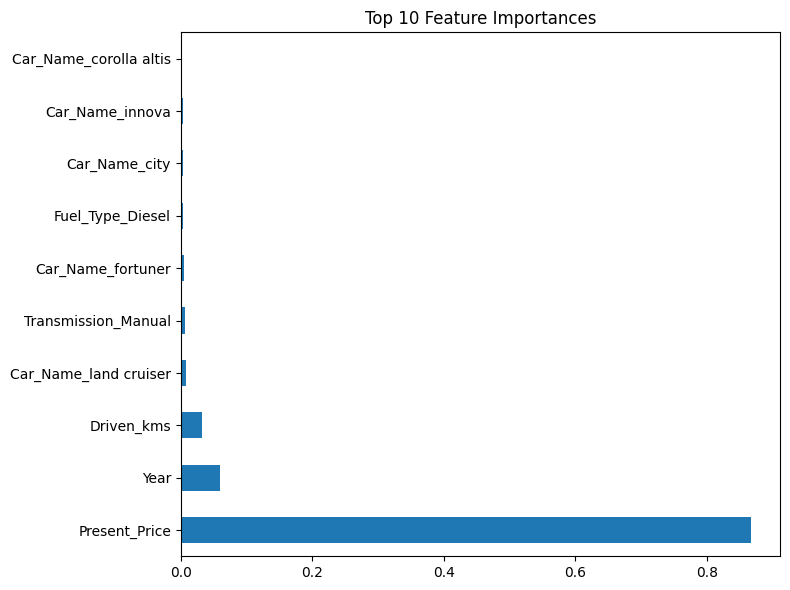

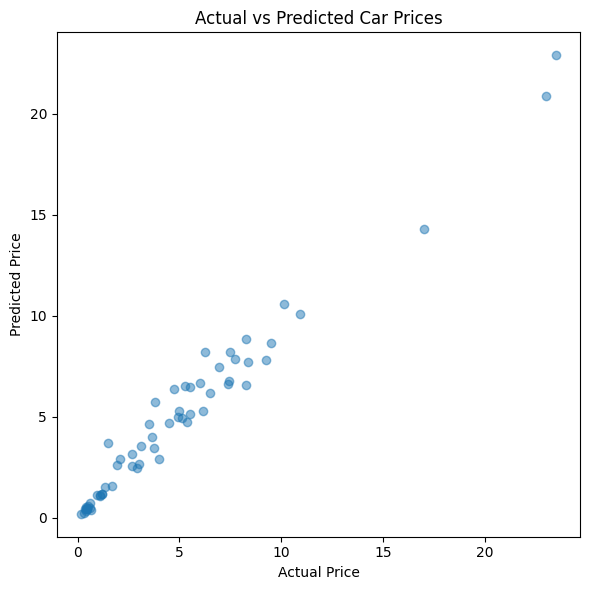

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Load data
df = pd.read_csv("CAR_DETAILS.csv")
print(df.head())
print("Missing values:\n", df.isnull().sum())
df.dropna(inplace=True)

# 2. Feature engineering: convert year to car age
current_year = 2026
if 'year' in df.columns:
    df['car_age'] = current_year - df['year']
    df.drop('year', axis=1, inplace=True)

if 'name' in df.columns:
    df.drop('name', axis=1, inplace=True)   # too many unique values, not useful directly

# 3. One-hot encode categorical features (fuel, seller_type, transmission, owner)
cat_cols = df.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 4. Train-test split
X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 6. Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# 7. Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
importances.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

# 8. Actual vs Predicted plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.show()